In [2]:
!pip install shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 10.1 MB/s eta 0:00:00


[LightGBM] [Info] Number of positive: 434, number of negative: 455
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 889, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.488189 -> initscore=-0.047253
[LightGBM] [Info] Start training from score -0.047253
[LightGBM] [Info] Number of positive: 434, number of negative: 455
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1348
[LightGBM] [Info] Number of data points in the train set: 889, number of used features: 14
[LightGBM] [Info] [binary:BoostF

/usr/local/lib/python3.10/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


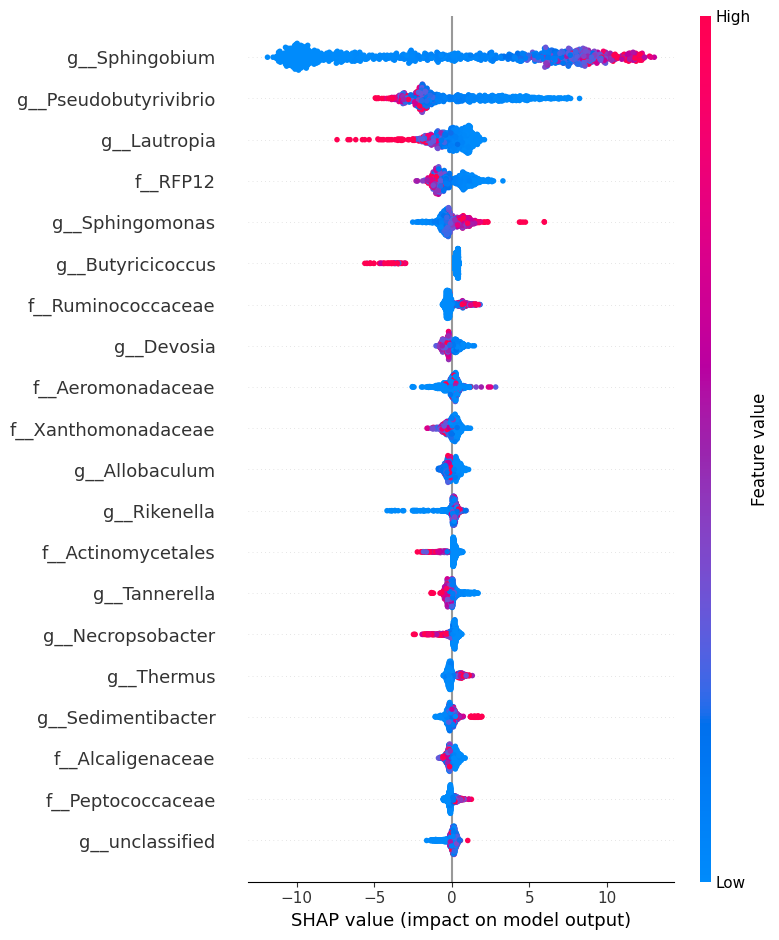

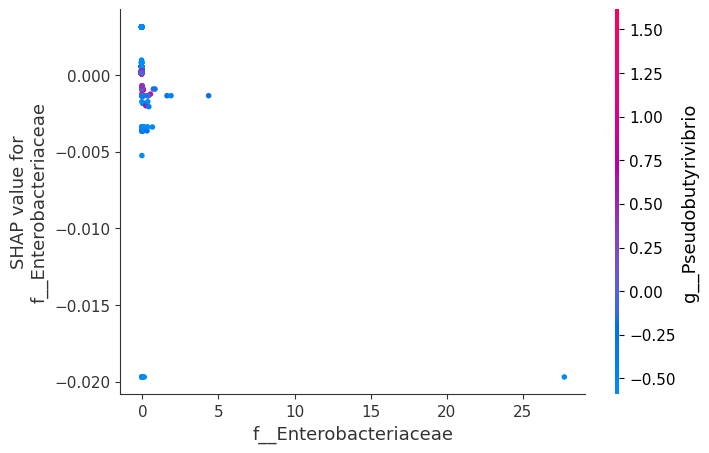

In [6]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import FeatureAgglomeration
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import shap

df = pd.read_csv('final_input.csv')
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

preprocess_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

X_train_preprocessed = preprocess_pipeline.fit_transform(X_train)
X_test_preprocessed = preprocess_pipeline.transform(X_test)

num_features = X_train_preprocessed.shape[1]

cluster_range = range(10, min(500, num_features + 1), 10)

best_accuracy = 0
optimal_clusters = 0


for n_clusters in cluster_range:
    pipeline = Pipeline([
        ('feature_agg', FeatureAgglomeration(n_clusters=n_clusters)),
        ('classifier', LGBMClassifier(random_state=42, n_estimators=200, num_leaves=31, learning_rate=0.1))
    ])

    pipeline.fit(X_train_preprocessed, y_train)

    y_pred = pipeline.predict(X_test_preprocessed)
    accuracy = accuracy_score(y_test, y_pred)


    if accuracy > best_accuracy:
        best_accuracy = accuracy
        optimal_clusters = n_clusters


final_pipeline = Pipeline([
    ('preprocessor', preprocess_pipeline),
    ('feature_agg', FeatureAgglomeration(n_clusters=optimal_clusters)),
    ('classifier', LGBMClassifier(random_state=42, n_estimators=200, num_leaves=31, learning_rate=0.1))
])

final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]


X_train_transformed = preprocess_pipeline.transform(X_train)

explainer = shap.TreeExplainer(final_pipeline.named_steps['classifier'])
shap_values = explainer.shap_values(final_pipeline.named_steps['feature_agg'].transform(X_train_transformed))

shap.summary_plot(shap_values, final_pipeline.named_steps['feature_agg'].transform(X_train_transformed), feature_names=X.columns)
shap.dependence_plot(0, shap_values, final_pipeline.named_steps['feature_agg'].transform(X_train_transformed), feature_names=X.columns)
